# Fisheries Conflict Analysis

## Load packages and data

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import random
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load WWF data set
df = pd.read_excel('data/WWF_data.xlsx')

# Preview the data
print(df.head())

                source_file     event_id       date  year           country  \
0  Oceania_No_AUS_NZL_Final  24328612817 2011-12-01  2011    American Samoa   
1  Oceania_No_AUS_NZL_Final  24359251958 2011-10-12  2011  French Polynesia   
2  Oceania_No_AUS_NZL_Final  24349703891 2011-08-01  2011              Guam   
3  Oceania_No_AUS_NZL_Final  24327648295 2011-11-10  2011              Guam   
4  Oceania_No_AUS_NZL_Final  24359264846 2011-10-13  2011         High Seas   

    region                                           Location  latitude  \
0  Oceania              Pago Pago, capital of American Samoa. -14.27806   
1  Oceania                 Port of Papeete, French Polynesia. -17.53600   
2  Oceania               Hotel Wharf, Port Authority of Guam.  13.46000   
3  Oceania                      Agana and Agat Marinas, Guam.  13.47567   
4  Oceania  Pacific high seas, near several Pacific island... -14.47300   

   longitude   loc_accuracy  ... FoodInsecurity Marginalization  StratLoc 

## Exploratory Data Analysis

In [3]:
# check NAs
print(df.isna().sum())

source_file                    0
event_id                       0
date                           0
year                           0
country                        0
region                         0
Location                       0
latitude                       0
longitude                      0
loc_accuracy                 218
Actor1                         0
Actor2                         0
WeakGov                        0
FishPop                        0
EcoChngeOther                  0
GroundsLim                     0
ForeignFisher                  0
IllegalFishing                 0
IncrEfficiency                 0
IncrPressure                 156
OpsScales                      0
Markets                        0
Poverty                        0
FoodInsecurity                 0
Marginalization                0
StratLoc                       0
MaritimeCrime                  0
violence_score                 0
ViolenceScore_Explanation    902
Explanation                    0
Summary   

In [4]:
# Count frequency of violence_score counts
df['violence_score'].value_counts()

violence_score
1    464
2    461
3    133
Name: count, dtype: int64

In [5]:
#Frequency of regions
df['region'].value_counts()

region
Horn of Africa    684
Arctic            162
Oceania           154
South America      56
South Asia          2
Name: count, dtype: int64

In [6]:
df.dtypes

source_file                          object
event_id                             object
date                         datetime64[ns]
year                                  int64
country                              object
region                               object
Location                             object
latitude                            float64
longitude                           float64
loc_accuracy                         object
Actor1                               object
Actor2                               object
WeakGov                               int64
FishPop                               int64
EcoChngeOther                         int64
GroundsLim                            int64
ForeignFisher                         int64
IllegalFishing                        int64
IncrEfficiency                        int64
IncrPressure                        float64
OpsScales                             int64
Markets                               int64
Poverty                         

In [7]:
pd.crosstab(df['region'], df['violence_score'])

violence_score,1,2,3
region,,,
Arctic,125,37,0
Horn of Africa,247,317,120
Oceania,84,61,9
South America,8,44,4
South Asia,0,2,0


## Data Cleaning and Analysis

In [8]:
# Columns of interest for analysis
data = df[[
    "region",
    "WeakGov", 
    "FishPop", 
    "EcoChngeOther", 
    "GroundsLim", 
    "ForeignFisher", 
    "IllegalFishing", 
    "IncrEfficiency", 
    "OpsScales",
    "Markets",
    "Poverty",
    "FoodInsecurity",
    "Marginalization",
    "StratLoc",
    "MaritimeCrime",
    "violence_score"
]]

# violence_score = 1 and violence_score = 2 become violence_score = 0, violence_score = 3 becomes violence_score 1
# phsycial harm vs not phsycial harm
new_response_values = {1: 0, 2: 0, 3: 1}
data_modified = data
data_modified['violence_score'] = data_modified['violence_score'].map(new_response_values)



C:\Users\ryans\AppData\Local\Temp\ipykernel_17828\4094210674.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_modified['violence_score'] = data_modified['violence_score'].map(new_response_values)


0       0
1       0
2       0
3       0
4       0
       ..
1053    0
1054    0
1055    1
1056    0
1057    0
Name: violence_score, Length: 1058, dtype: int64

In [9]:
# Filter by region
def regional_filtering(data, region_string = None):
    if region_string is None:
        filtered = data
    elif region_string not in data['region'].values:
        valid_regions = data['region'].unique().tolist()
        raise ValueError(f"{region_string} is not a valid region in the dataset. These are the available options: {valid_regions}.")
    else:
        filtered = data[data['region'] == region_string]
    return filtered

# filtered = regional_filtering(data)

In [10]:
# Split data into training and testing groups
#Input: filtered data with 'region' variable from regional_filtering
def split_data(data):
    data2 = data.drop(columns = ['region'])
    X = data2.loc[:, data2.columns != 'violence_score']
    y = data2['violence_score']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state=42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(data)
X_test


,WeakGov,FishPop,EcoChngeOther,GroundsLim,ForeignFisher,IllegalFishing,IncrEfficiency,OpsScales,Markets,Poverty,FoodInsecurity,Marginalization,StratLoc,MaritimeCrime
457,0,0,0,1,0,0,0,0,0,0,0,0,0,0
289,0,1,0,1,0,0,0,0,0,0,0,0,0,0
323,1,1,0,0,0,1,1,0,0,0,0,0,0,0
31,0,1,1,0,0,1,1,0,0,0,0,0,0,0
428,1,0,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,0,1,0,1,1,1,0,0,1,0,0,0,0,0
72,0,1,0,1,1,0,0,1,0,0,0,0,0,0
334,0,1,0,0,1,0,1,0,0,0,0,0,0,0
44,0,0,0,1,0,1,1,0,0,0,0,0,0,0


In [38]:
def models(X_train, y_train):
    feature_names = X_train.columns 

    model_params = [
        {
            'name': 'Logistic Regression',
            'estimator': LogisticRegression(
                penalty='elasticnet',
                solver='saga',
                random_state=42,
                max_iter = 2500
            ),
            'param_grid': {
                'l1_ratio': np.linspace(0, 1, 5),
                'C': np.linspace(.01, 10, 5),
                'class_weight': [None, 'balanced']
            }
        },

        {
            'name': 'Random Forest',
            'estimator': RandomForestClassifier(class_weight = 'balanced', random_state=42),
            'param_grid': {
                'n_estimators': np.linspace(20, 250, 25).astype(int),
                'max_depth': [4, 7],
                'min_samples_split': [3, 5]
            }
        }
    ]

    cv_strategy = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42) 
    scoring = {
        'accuracy': 'accuracy',
        'f1': 'f1_weighted',
        'roc_auc': 'roc_auc_ovr'}

    results = []

    for item in model_params:
        grid = GridSearchCV(
            item['estimator'],
            item['param_grid'],
            cv=cv_strategy,
            scoring=scoring,
            refit='accuracy',
            n_jobs = -1
        )

        grid.fit(X_train, y_train)

        model_name = item['name']

        
        for i, params in enumerate(grid.cv_results_['params']):

            # fit model for each parameter set
            temp_model = grid.estimator.set_params(**params)
            temp_model.fit(X_train, y_train)

            # feature selection per model
            if hasattr(temp_model, "coef_"): #for log reg
                coef = temp_model.coef_
                mask = np.any(np.abs(coef) > 1e-3, axis=0)

            elif hasattr(temp_model, "feature_importances_"): # for random forest
                importances = temp_model.feature_importances_
                mask = importances > 0

            else:
                mask = np.ones(len(feature_names), dtype=bool)

            selected_features = feature_names[mask]
            non_zero = np.sum(mask)

            results.append({
                'model': item['name'],
                'params': params,
                'training_data_accuracy': grid.cv_results_['mean_test_accuracy'][i],
                'f1': grid.cv_results_['mean_test_f1'][i],
                'roc_auc': grid.cv_results_['mean_test_roc_auc'][i],
                'non_zero_features': non_zero,
                'selected_features': list(selected_features),
                'mean_fit_time': grid.cv_results_['mean_fit_time'][i]
            })

    results_df = pd.DataFrame(results)

    # sort highest accuracy to lowest
    results_df = results_df.sort_values('training_data_accuracy', ascending=False).reset_index(drop=True)
    
    best_models = (
                    results_df
                    .sort_values('training_data_accuracy', ascending=False)
                    .groupby('model', as_index=False)
                    .first()
                    )

    return results_df, best_models

results_df, best_models = models(X_train, y_train)

In [12]:
best_models

,model,params,training_data_accuracy,f1,roc_auc,non_zero_features,selected_features,mean_fit_time
0,Logistic Regression,"{'C': 101157.94542598983, 'class_weight': None...",0.868820,0.825282,0.722542,14,"[WeakGov, FishPop, EcoChngeOther, GroundsLim, ...",0.085152
1,Random Forest,"{'max_depth': 7, 'min_samples_split': 5, 'n_es...",0.739972,0.778812,0.770286,14,"[WeakGov, FishPop, EcoChngeOther, GroundsLim, ...",0.109162


In [32]:
# Assess performance with best models on test data
def assessment(best_models, X_train, y_train, X_test, y_test):
    #loop through each row of best_models
    for index, row in best_models.iterrows():
        model = row['model']
        params = row['params'] #dict

        # train model again with 'best' params and assess model on test data
        if model == 'Logistic Regression':
            model = LogisticRegression(**row['params'],
                            penalty= 'elasticnet',
                            solver='saga',
                            max_iter=3000,
                            tol = 1e-4,
                            random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            # y_probability = pd.DataFrame(model.predict_proba(X_test), y_test) # compare violence_score to likelihood datapoint is each conflict type
        
            
            # Classification report
            display('Logistic Regression Results:')
            # print(classification_report(y_test, y_pred)) 
            

            #  df of intercept, coefs, and odds_ratio with variable names
            coef_df = pd.DataFrame(
                np.vstack([model.intercept_, model.coef_.T]),
                index=["Intercept"] + list(model.feature_names_in_),
                ).reset_index()
            coef_df.columns = ["Variable", "response_1_coef"]
            coef_df["odds_ratio_1"] = np.exp(coef_df["response_1_coef"])
            ordered_columns = [
                        "Variable",
                        "response_1_coef",
                        "odds_ratio_1",
                    ]
            coef_df = coef_df[ordered_columns]
            display(coef_df)


        if model == 'Random Forest':
            model = RandomForestClassifier(**row['params'], random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        
            display("Random Forest Results:")
            # feature importance
            importances = model.feature_importances_
            feature_names = model.feature_names_in_
            feature_imp_df = pd.DataFrame({'Feature': feature_names, 
                                           'Gini Importance': importances
                                           }).sort_values('Gini Importance', ascending=False)
            display(feature_imp_df)

            plt.figure()
            plt.barh(feature_imp_df['Feature'], feature_imp_df['Gini Importance'])
            plt.xlabel('Gini Importance')
            plt.title('Feature Importance - Gini Importance')
            plt.gca().invert_yaxis() # feature with largest importance on top
            plt.show()


        # Classification report
        print(classification_report(y_test, y_pred)) 

        # Confusion matrix 
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        plt.figure()
        disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
        disp.plot(cmap = plt.cm.Blues)
        plt.title(f"Confusion Matrix: {row['model']}")
        plt.xlabel('Prediction')
        plt.ylabel('Actual')
        plt.show()

'Logistic Regression Results:'

,Variable,response_1_coef,odds_ratio_1
0,Intercept,-1.623992,0.197110
1,WeakGov,0.000000,1.000000
2,FishPop,-0.980722,0.375040
3,EcoChngeOther,-0.505591,0.603149
4,GroundsLim,0.016036,1.016165
5,ForeignFisher,0.000000,1.000000
6,IllegalFishing,-0.286462,0.750915
7,IncrEfficiency,0.000000,1.000000
8,OpsScales,0.202229,1.224128
9,Markets,-1.358974,0.256924


              precision    recall  f1-score   support

           0       0.80      0.98      0.88       109
           1       0.50      0.07      0.12        28

    accuracy                           0.80       137
   macro avg       0.65      0.53      0.50       137
weighted avg       0.74      0.80      0.73       137



<Figure size 640x480 with 0 Axes>

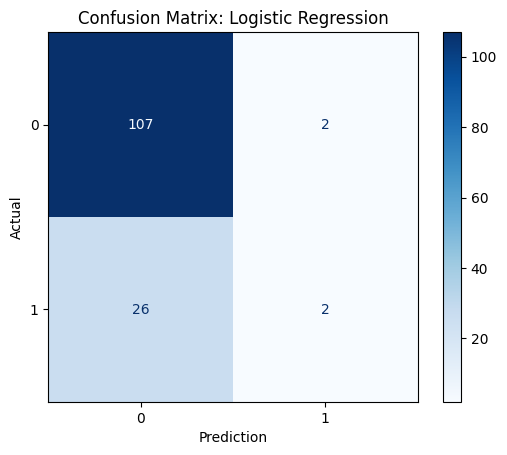

'Random Forest Results:'

,Feature,Gini Importance
11,Marginalization,0.161831
0,WeakGov,0.114836
1,FishPop,0.101970
12,StratLoc,0.093055
13,MaritimeCrime,0.092308
3,GroundsLim,0.084231
2,EcoChngeOther,0.070243
5,IllegalFishing,0.065511
4,ForeignFisher,0.053414
6,IncrEfficiency,0.047143


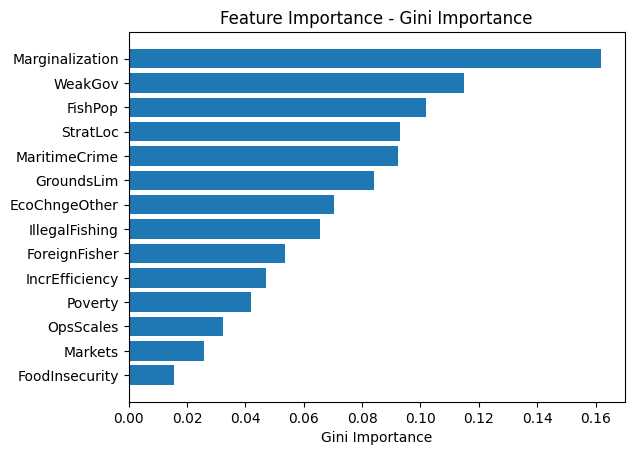

              precision    recall  f1-score   support

           0       0.81      1.00      0.89       109
           1       1.00      0.07      0.13        28

    accuracy                           0.81       137
   macro avg       0.90      0.54      0.51       137
weighted avg       0.85      0.81      0.74       137



<Figure size 640x480 with 0 Axes>

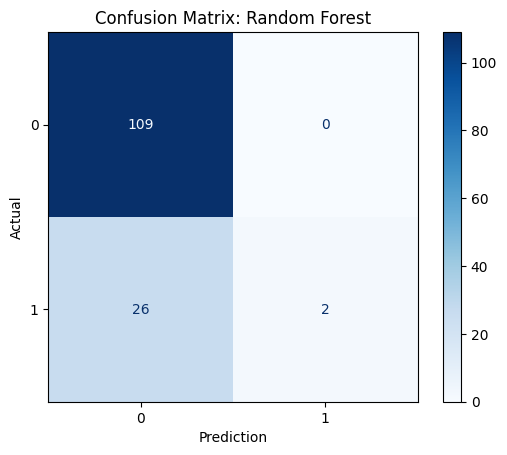

In [33]:
# Run all analysis
def analysis(data, region = None):
    filtered_data = regional_filtering(data, region)
    X_train, X_test, y_train, y_test = split_data(filtered_data)
    results_df, best_models = models(X_train, y_train)
    assessment(best_models, X_train, y_train, X_test, y_test)

analysis(data_modified, 'Horn of Africa')

## Analysis with temp variable added

In [ ]:
df_with_sst_ocean_2 = pd.read_csv('data/data_with_temps.csv')


In [34]:
from sklearn.preprocessing import MinMaxScaler

data2 = df_with_sst_ocean_2[[
    "region",
    "WeakGov", 
    "FishPop", 
    "EcoChngeOther", 
    "GroundsLim", 
    "ForeignFisher", 
    "IllegalFishing", 
    "IncrEfficiency", 
    "OpsScales",
    "Markets",
    "Poverty",
    "FoodInsecurity",
    "Marginalization",
    "StratLoc",
    "MaritimeCrime",
    "violence_score",
    'sst_degC'
]]

scaler = MinMaxScaler()
data2['sst_degC'] = scaler.fit_transform(data2[['sst_degC']])

# violence_score = 1 and violence_score = 2 become violence_score = 0
# violence_score = 3 becomes violence_score 1 (phsycial harm vs not phsycial harm)
new_response_values = {1: 0, 2: 0, 3: 1}
data_modified_2 = data2
data_modified_2['violence_score'] = data_modified_2['violence_score'].map(new_response_values)

data_modified_2

C:\Users\ryans\AppData\Local\Temp\ipykernel_17828\2035715856.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['sst_degC'] = scaler.fit_transform(data2[['sst_degC']])
C:\Users\ryans\AppData\Local\Temp\ipykernel_17828\2035715856.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_modified_2['violence_score'] = data_modified_2['violence_score'].map(new_response_values)


,region,WeakGov,FishPop,EcoChngeOther,GroundsLim,ForeignFisher,IllegalFishing,IncrEfficiency,OpsScales,Markets,Poverty,FoodInsecurity,Marginalization,StratLoc,MaritimeCrime,violence_score,sst_degC
0,Oceania,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.891099
1,Oceania,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.825898
2,Oceania,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.913673
3,Oceania,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0.900758
4,Oceania,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0.876419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,South America,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.697008
1051,South America,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.697008
1052,South America,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.703727
1053,South America,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0.747413


'Logistic Regression Results:'

,Variable,response_1_coef,odds_ratio_1
0,Intercept,3.891189,48.969073
1,WeakGov,0.120538,1.128104
2,FishPop,-1.782547,0.168209
3,EcoChngeOther,-0.248041,0.780328
4,GroundsLim,0.001959,1.001961
5,ForeignFisher,-0.029033,0.971384
6,IllegalFishing,-0.027994,0.972395
7,IncrEfficiency,-0.089036,0.914813
8,OpsScales,-0.323164,0.723855
9,Markets,-6.790352,0.001125


              precision    recall  f1-score   support

           0       0.85      0.91      0.88       114
           1       0.29      0.17      0.22        23

    accuracy                           0.79       137
   macro avg       0.57      0.54      0.55       137
weighted avg       0.75      0.79      0.77       137



<Figure size 640x480 with 0 Axes>

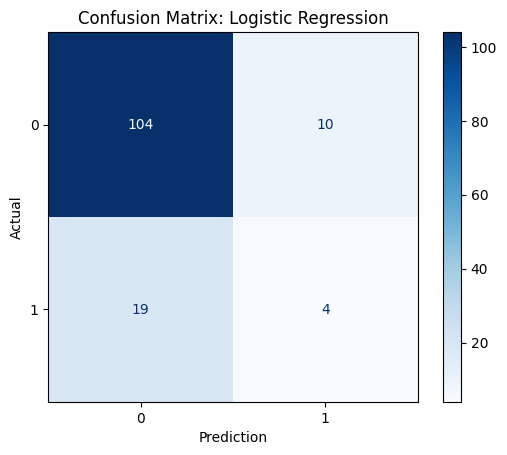

'Random Forest Results:'

,Feature,Gini Importance
14,sst_degC,0.300433
11,Marginalization,0.143352
12,StratLoc,0.098534
1,FishPop,0.069400
0,WeakGov,0.066736
13,MaritimeCrime,0.058002
3,GroundsLim,0.051966
4,ForeignFisher,0.039226
6,IncrEfficiency,0.038006
5,IllegalFishing,0.036363


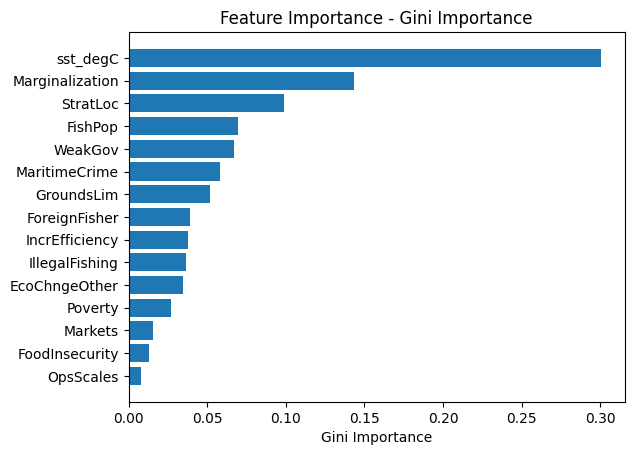

              precision    recall  f1-score   support

           0       0.84      0.96      0.89       114
           1       0.29      0.09      0.13        23

    accuracy                           0.81       137
   macro avg       0.56      0.52      0.51       137
weighted avg       0.75      0.81      0.77       137



<Figure size 640x480 with 0 Axes>

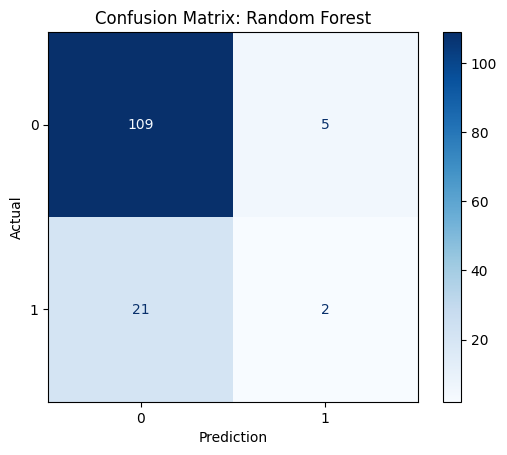

In [35]:
def analysis(data2, region = None):
    filtered_data = regional_filtering(data2, region)
    X_train, X_test, y_train, y_test = split_data(filtered_data)    
    results_df, best_models = models(X_train, y_train)
    assessment(best_models, X_train, y_train, X_test, y_test)


analysis(data_modified_2, "Horn of Africa")

In [40]:
results_df

,model,params,training_data_accuracy,f1,roc_auc,non_zero_features,selected_features,mean_fit_time
0,Logistic Regression,"{'C': 0.01, 'class_weight': None, 'l1_ratio': ...",0.874709,0.816252,0.736918,14,"[WeakGov, FishPop, EcoChngeOther, GroundsLim, ...",0.008827
1,Logistic Regression,"{'C': 0.01, 'class_weight': None, 'l1_ratio': ...",0.874709,0.816252,0.500000,1,[FishPop],0.006144
2,Logistic Regression,"{'C': 0.01, 'class_weight': None, 'l1_ratio': ...",0.874709,0.816252,0.500000,0,[],0.004974
3,Logistic Regression,"{'C': 0.01, 'class_weight': None, 'l1_ratio': ...",0.874709,0.816252,0.500000,0,[],0.005927
4,Logistic Regression,"{'C': 0.01, 'class_weight': None, 'l1_ratio': ...",0.874709,0.816252,0.500000,0,[],0.003139
...,...,...,...,...,...,...,...,...
145,Logistic Regression,"{'C': 10.0, 'class_weight': 'balanced', 'l1_ra...",0.687943,0.738532,0.730302,13,"[WeakGov, FishPop, EcoChngeOther, GroundsLim, ...",0.022986
146,Logistic Regression,"{'C': 0.01, 'class_weight': 'balanced', 'l1_ra...",0.615747,0.661061,0.703054,4,"[FishPop, EcoChngeOther, Marginalization, Mari...",0.006392
147,Logistic Regression,"{'C': 0.01, 'class_weight': 'balanced', 'l1_ra...",0.574118,0.500149,0.500000,0,[],0.004634
148,Logistic Regression,"{'C': 0.01, 'class_weight': 'balanced', 'l1_ra...",0.536471,0.482173,0.497727,2,"[FishPop, MaritimeCrime]",0.005963


## Forward selection

In [ ]:
# RF forward selection: https://www.youtube.com/watch?v=POCvLGRLDzM

## References
- Creating a correlation matrix: https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/
- different solvers explanation: https://stackoverflow.com/questions/38640109/logistic-regression-python-solvers-definitions
- Logistic regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Confusion Matrix chart: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/
- Feature Importance chart: https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests/